In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [4]:
from src.misc.metrics import *

result_folder = "results/M3-Max/llama3.2-vision_11b-qwen2.5_14b"

db_filepath = f"{result_folder}/emails.db"
metrics = calculate_metrics(db_filepath)
df = metrics["df"]
del metrics["df"]
metrics

{'task_completion_rate': 1,
 'task_success_rate': 0.9702020202020202,
 'total_execution_time': 118897.62412,
 'mean_execution_time': 60.04930511111111,
 'std_execution_time': 20.52772141510193,
 'mean_process_steps': 8.562626262626262,
 'std_process_steps': 1.6575480566481935,
 'total_tasks': 1980,
 'SUCCESS': 1921,
 'DB_QUERY_TOOL_NOT_INITIALIZED': 39,
 'DB_UPDATE_TOOL_NOT_INITIALIZED': 16,
 'DB_QUERY_TOOL_ARGS_MISMATCH': 2,
 'OCR_TOOL_RESULT_MISMATCH': 1,
 'DB_UPDATE_TOOL_ARGS_MISMATCH': 1}

In [5]:
df.head(5)

,email_id,sender_email,recipient_email,subject,email_body,attachments,process_status,response,start_time,end_time,...,total_time,successful_requests,total_tokens,prompt_tokens,completion_tokens,total_cost,original_process_status,process_steps,duration,duration_hms
0,93185A89130149C0A842968E4AFDCAA2,RobinLevine@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 43925,Hi Tanya ! Please find attached payment screen...,transaction_1.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-13 18:10:11.605385,2025-04-13 18:11:41.429034,...,89.8236,6,2559,2088,471,0.0,SUCCESS,9,89.823649,0 days 00:01:29
1,614972488B7B411BAEA4814CF066CDAA,StevenNixon@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 51782,Hi Tanya ! Please find attached payment screen...,transaction_2.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-13 18:11:41.431054,2025-04-13 18:12:53.295190,...,71.8641,6,2408,2070,338,0.0,SUCCESS,9,71.864136,0 days 00:01:11
2,C484ABEB38F44D29960B1CEF58510627,MadisonFord@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 42968,Hi Tanya ! Please find attached payment screen...,transaction_3.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-13 18:12:53.297830,2025-04-13 18:14:11.622870,...,78.3250,6,2616,2180,436,0.0,SUCCESS,9,78.325040,0 days 00:01:18
3,706B3403E8024178948B3BFBF9E64A25,KathrynJones@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 92948,Hi Tanya ! Please find attached payment screen...,transaction_4.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-13 18:14:11.624528,2025-04-13 18:15:17.327825,...,65.7033,6,2297,2006,291,0.0,SUCCESS,9,65.703297,0 days 00:01:05
4,86838440CA6C472AACFA3FCE1382609C,ChristineOwens@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 20304,Hi Tanya ! Please find attached payment screen...,transaction_5.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-13 18:15:17.330818,2025-04-13 18:16:34.668076,...,77.3373,6,2605,2191,414,0.0,SUCCESS,9,77.337258,0 days 00:01:17


In [6]:
import matplotlib.pyplot as plt


def plot_value_distribution(df_filtered, col="category", top_n=10):
    df_filtered[col].value_counts()[:top_n].plot(kind="bar")
    plt.title(f"Distribution of {col}")

    # add the count on top of the bars
    for i in range(len(df_filtered[col].value_counts()[:top_n])):
        count = df_filtered[col].value_counts().values[i]
        plt.text(i, count, count, ha="center")

    plt.show()

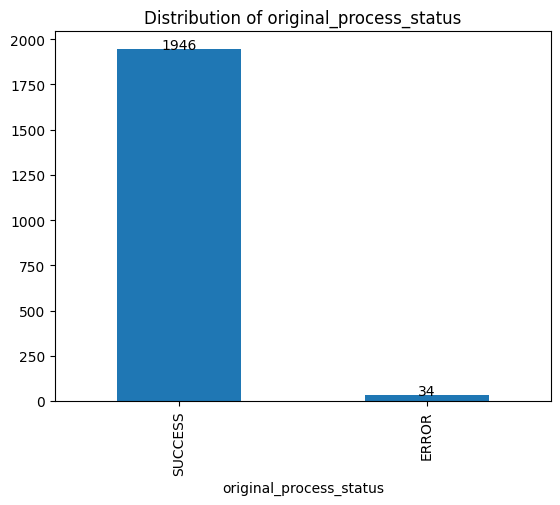

In [7]:
plot_value_distribution(df, "original_process_status")

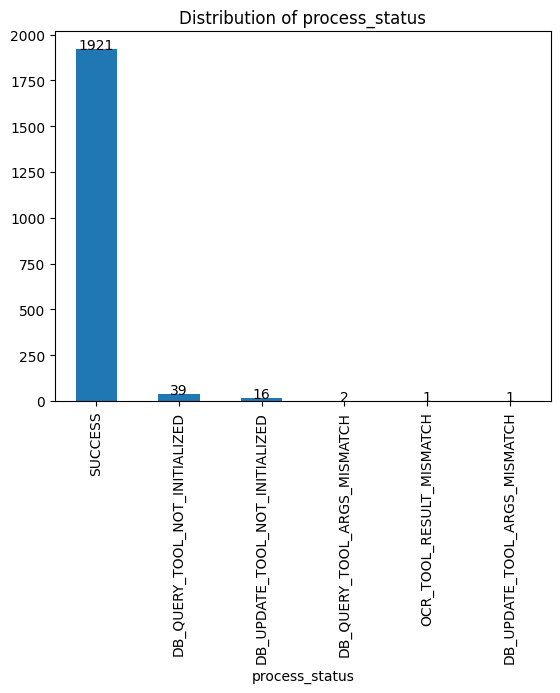

In [8]:
plot_value_distribution(df, "process_status")

In [9]:
print_row_details(df, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: SUCCESS
--------------------------------------------------
response: {"content": "DONE"}
--------------------------------------------------
start_time: 2025-04-13 18:10:11.605385
--------------------------------------------------
end_time: 2025-04-13 18:11:41.429034
-----------------------------------------

In [10]:
import json

logs = json.loads(df.iloc[0]["full_logs"])
len(logs)

9

In [11]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-04-13T18:10:11.605385",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-13T18:10:15.338139",


In [12]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 538\\nSent by: Robin Levine\\nYou paid $196 to Tanya\\nTransaction Reference Number: EC4F9FE854344D25\\nTransaction Date: 04/23/23\\nInvoice ID: 43925\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 139, \"prompt_tokens\": 90, \"completion_tokens\": 49, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-13T18:10:15.338139",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"43925\", \"bank_name\": \"Bank 538\", \"transaction_id\": \"EC4F9FE854344D25\", \"amount\": \"$196.00\", \"rec

3

In [13]:
df["process_status"].value_counts()

process_status
SUCCESS                           1921
DB_QUERY_TOOL_NOT_INITIALIZED       39
DB_UPDATE_TOOL_NOT_INITIALIZED      16
DB_QUERY_TOOL_ARGS_MISMATCH          2
OCR_TOOL_RESULT_MISMATCH             1
DB_UPDATE_TOOL_ARGS_MISMATCH         1
Name: count, dtype: int64

In [14]:
df_filtered = (
    df[df["attachments"] == ""].copy().reset_index(drop=True)
)
len(df_filtered)

990

In [15]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: E-93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 1043925
--------------------------------------------------
email_body: Dear Tanya, I hope this message finds you well.I am writing to confirm that we have successfully made the payment for Invoice ID: 1043925, related to our recent order with you. Here are the details:  
Invoice ID: 1043925
Invoice Date: 4/23/23
Total Amount paid: 196.0
Transaction Reference Number - T-EC4F9FE854344D25
Thank you and I look forward to our continued business
Best regards,
Robin Levine
--------------------------------------------------
attachments: 
--------------------------------------------------
process_status: SUCCESS
----------

In [16]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

8

In [17]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 1043925\n            Body: Dear Tanya, I hope this message finds you well.I am writing to confirm that we have successfully made the payment for Invoice ID: 1043925, related to our recent order with you. Here are the details:  \nInvoice ID: 1043925\nInvoice Date: 4/23/23\nTotal Amount paid: 196.0\nTransaction Reference Number - T-EC4F9FE854344D25\nThank you and I look forward to our continued business\nBest regards,\nRobin Levine\n            \n            \n                ",
    "timestamp": "2025-04-14T14:50:30.227906",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output

In [18]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"1043925\", \"bank_name\": \"Bank 538\", \"transaction_id\": \"T-EC4F9FE854344D25\", \"amount\": \"$196.00\", \"recipient_name\": \"Tanya\", \"sender_name\": \"Robin Levine\"}}",
    "timestamp": "2025-04-14T14:50:39.216831",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_update_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"DONE\"}",
    "timestamp": "2025-04-14T14:50:57.659143",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
   

2

In [19]:
df_filtered = (
    df[df["process_status"] == "OCR_TOOL_RESULT_MISMATCH"].copy().reset_index(drop=True)
)
len(df_filtered)

1

In [20]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: 1DB13CBF8EF746BFB329E0F89C73600E
--------------------------------------------------
sender_email: JamesPhillips@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 57267
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 57267 , Regards James Phillips
--------------------------------------------------
attachments: transaction_589.jpeg
--------------------------------------------------
process_status: OCR_TOOL_RESULT_MISMATCH
--------------------------------------------------
response: {"content": "DONE"}
--------------------------------------------------
start_time: 2025-04-14 06:11:28.146735
--------------------------------------------------
end_time: 2025-04-14 06:13:22.664209
------------------

In [21]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

9

In [22]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: JamesPhillips@example.com\n            Subject: Payment Confirmation for Invoice ID: 57267\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 57267 , Regards James Phillips\n            Attachment: transaction_589.jpeg\n            \n                ",
    "timestamp": "2025-04-14T06:11:28.146735",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-14T06:11:32.945

In [23]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"**Bank Information**\\n* Bank Name: Bank 617\\n* Sent by: James Phillips\\n\\n**Transaction Details**\\n* Payment Amount: $89\\n* Recipient: Tanya\\n\\n**Reference Number and Transaction Date**\\n* Reference Number: F5497136AF6746B2\\n* Transaction Date: April 20, 2023\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 160, \"prompt_tokens\": 90, \"completion_tokens\": 70, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-14T06:11:32.945779",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\"

3

In [ ]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 57267"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [25]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 57267
--------------------------------------------------
bank_name: Bank 617
--------------------------------------------------
transaction_id: F5497136AF6746B2
--------------------------------------------------
amount: 89.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: James Phillips
--------------------------------------------------
reconciliation_state: PAID
--------------------------------------------------
email_details: Senior Reconciliation Agent: UPDATE Invoice ID 57267 - The email content and the data from the OCR tool match the information in our database. Please proceed to update the reconciliation status for this invoice as it has been successfully matched.
- Sender: JamesPhillips@example.com
- Subject: Payment Confirmation for Invoice ID: 57267
- Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 572

In [26]:
query = "SELECT * FROM transactions WHERE reconciliation_state = 'UNPAID'"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

43